# What-if Scenario Analysis for Data Centre Hosting

This notebook explores hypothetical scenarios for data centre expansion across different countries.

**Purpose:**
- Analyze how different levels of AI/data centre demand would impact national electricity grids
- Compare carbon footprints across hosting locations
- Understand grid capacity constraints in different countries
- Support strategic recommendations for sustainable data centre placement

## 1. Data Download

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# 1. OWID energy dataset
# =========================================
owid_url = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
energy = pd.read_csv(owid_url)

In [2]:
energy.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [3]:
energy.shape

(23232, 130)

## 2. Define Analysis Parameters

**Peer Countries:**
- Selected based on data centre hosting potential and data availability
- Includes diverse electricity profiles (clean vs. fossil-heavy grids)
- Note: United States excluded from comparative analysis

**Scenario Parameters:**
- Analysis year: 2024 (latest available data)
- AI workload scenarios: 1 TWh, 5 TWh, and 10 TWh of additional electricity demand

In [4]:
peer_countries = ['Canada', 'Ireland', 'France', 'Norway', 'Sweden', 'Mexico', 'South Korea', 'Turkey', 'Chad', 'Chile', 'China', 'Colombia',
                  'Congo', 'Costa Rica', 'Croatia', 'Cuba', 'Curacao', 'Cyprus','Czechia', 'Democratic Republic of Congo', 'Denmark',
                  'Ukraine', 'United Arab Emirates', 'United Kingdom']
year_for_analysis = 2024
scenarios_twh = [1, 5, 10]

## 3. Select Key Metrics

**Metrics for analysis:**
- `electricity_demand`: Total national electricity demand (TWh) - indicates grid capacity
- `low_carbon_share_elec`: Percentage of electricity from low-carbon sources (renewables + nuclear)
- `carbon_intensity_elec`: gCO₂ per kWh - direct measure of grid cleanliness

In [5]:
cols_to_stay = [
    "country",
    "year",
    "electricity_demand",
    "low_carbon_share_elec",
    "carbon_intensity_elec",
]

## 4. Filter and Prepare 2024 Dataset

Extract 2024 data for selected countries and remove any rows with missing values in key metrics.

In [8]:
df2024 = (
    energy.loc[
        (energy["country"].isin(peer_countries)) &
        (energy["year"] == year_for_analysis),
        cols_to_stay
    ]
    .copy()
)

df2024 = df2024.dropna(subset = ['electricity_demand', 'low_carbon_share_elec', 'carbon_intensity_elec'])
df2024.head()

,country,year,electricity_demand,low_carbon_share_elec,carbon_intensity_elec
3912,Canada,2024,624.29,77.694,185.35
4450,Chile,2024,89.26,69.897,265.18
4575,China,2024,10072.95,38.165,555.40
4700,Colombia,2024,91.74,64.358,285.80
4958,Costa Rica,2024,11.53,94.023,63.01


In [10]:
df2024.shape

(19, 5)

## 5. Calculate Scenario Impacts

**Two key calculations:**

1. **Grid Pressure:** What percentage of national electricity would AI/data centres consume?
   - Formula: `share_of_demand (%) = extra_twh / electricity_demand * 100`
   - Small grids face higher percentage pressure from the same absolute demand

2. **Carbon Emissions:** How much CO₂ would be emitted from 10 TWh of data centre demand?
   - Formula: `MtCO2 = carbon_intensity * 10 TWh`
   - Clean grids (low carbon intensity) produce fewer emissions per TWh

In [11]:
# =========================================
# 5. New AI Workload Scenarios
# Formula:
# share_of_demand (%) = extra_twh / electricity_demand * 100
# =========================================
for s in scenarios_twh:
    df2024[f"share_{s}twh_pct"] = s / df2024["electricity_demand"] * 100

# emissions from 10 TWh
# carbon_intensity_elec in gCO2/kWh
# 1 TWh = 1e9 kWh
# MtCO2 = intensity * 1e9 / 1e12 = intensity / 1000
df2024["mtco2_for_10twh"] = df2024["carbon_intensity_elec"] / 1000 * 10

In [12]:
df2024

,country,year,electricity_demand,low_carbon_share_elec,carbon_intensity_elec,share_1twh_pct,share_5twh_pct,share_10twh_pct,mtco2_for_10twh
3912,Canada,2024,624.29,77.694,185.35,0.160182,0.800910,1.601820,1.8535
4450,Chile,2024,89.26,69.897,265.18,1.120323,5.601613,11.203227,2.6518
4575,China,2024,10072.95,38.165,555.40,0.009928,0.049638,0.099276,5.5540
4700,Colombia,2024,91.74,64.358,285.80,1.090037,5.450185,10.900371,2.8580
4958,Costa Rica,2024,11.53,94.023,63.01,8.673027,43.365134,86.730269,0.6301
5117,Croatia,2024,19.48,73.148,172.62,5.133470,25.667351,51.334702,1.7262
5363,Cyprus,2024,5.66,23.145,514.13,17.667845,88.339223,176.678445,5.1413
5424,Czechia,2024,66.16,57.690,414.17,1.511487,7.557437,15.114873,4.1417
5768,Denmark,2024,38.89,89.227,131.33,2.571355,12.856776,25.713551,1.3133
7760,France,2024,470.13,94.883,40.83,0.212707,1.063536,2.127071,0.4083


## 6. Categorize Grid Pressure

**Pressure Categories:**
- **Low pressure** (<1%): Large grids can absorb 10 TWh with minimal impact
- **Moderate pressure** (1-3%): Noticeable but manageable grid impact
- **High pressure** (>3%): Significant strain on national electricity system

This helps identify which countries have the infrastructure capacity for large-scale data centre hosting.

In [14]:
# =========================================
# 6. Simple heuristics based on pressure level
# =========================================
def pressure_label(x):
    if x < 1:
        return "Low"
    elif x < 3:
        return "Moderate"
    else:
        return "High"

df2024["pressure_10twh"] = df2024["share_10twh_pct"].apply(pressure_label)

In [15]:
df2024.head()

,country,year,electricity_demand,low_carbon_share_elec,carbon_intensity_elec,share_1twh_pct,share_5twh_pct,share_10twh_pct,mtco2_for_10twh,pressure_10twh
3912,Canada,2024,624.29,77.694,185.35,0.160182,0.800910,1.601820,1.8535,Moderate
4450,Chile,2024,89.26,69.897,265.18,1.120323,5.601613,11.203227,2.6518,High
4575,China,2024,10072.95,38.165,555.40,0.009928,0.049638,0.099276,5.5540,Low
4700,Colombia,2024,91.74,64.358,285.80,1.090037,5.450185,10.900371,2.8580,High
4958,Costa Rica,2024,11.53,94.023,63.01,8.673027,43.365134,86.730269,0.6301,High


In [16]:
df2024 = df2024.sort_values("share_10twh_pct", ascending=False).reset_index(drop=True)

print("\n=== Main Table for Scenario Analysis ===")
print(
    df2024[
        [
            "country",
            "electricity_demand",
            "low_carbon_share_elec",
            "carbon_intensity_elec",
            "share_1twh_pct",
            "share_5twh_pct",
            "share_10twh_pct",
            "pressure_10twh",
        ]
    ]
    .round(3)
    .to_string(index=False)
)


=== Main Table for Scenario Analysis ===
             country  electricity_demand  low_carbon_share_elec  carbon_intensity_elec  share_1twh_pct  share_5twh_pct  share_10twh_pct pressure_10twh
              Cyprus                5.66                 23.145                 514.13          17.668          88.339          176.678           High
          Costa Rica               11.53                 94.023                  63.01           8.673          43.365           86.730           High
             Croatia               19.48                 73.148                 172.62           5.133          25.667           51.335           High
             Ireland               36.02                 46.027                 273.26           2.776          13.881           27.762           High
             Denmark               38.89                 89.227                 131.33           2.571          12.857           25.714           High
             Czechia               66.16            

## 7. Visualizations

The following charts compare countries across:
- Grid pressure from data centre demand (low, moderate, high)
- Carbon emissions impact
- Low-carbon electricity availability

These visualizations support strategic recommendations for sustainable data centre placement.

In [18]:
# =========================================
# 7. Long format table for graphs
# =========================================
scenario_cols = [f"share_{s}twh_pct" for s in scenarios_twh]

plot_df = df2024[["country"] + scenario_cols].copy()
plot_long = plot_df.melt(
    id_vars="country",
    value_vars=scenario_cols,
    var_name="scenario",
    value_name="share_pct"
)

scenario_name_map = {
    "share_1twh_pct": "1 TWh",
    "share_5twh_pct": "5 TWh",
    "share_10twh_pct": "10 TWh"
}
plot_long["scenario"] = plot_long["scenario"].map(scenario_name_map)

print("\n=== AI Workload Share of Annual Demand (%) ===")
print(plot_long.round(3).to_string(index=False))


=== AI Workload Share of Annual Demand (%) ===
             country scenario  share_pct
              Cyprus    1 TWh     17.668
          Costa Rica    1 TWh      8.673
             Croatia    1 TWh      5.133
             Ireland    1 TWh      2.776
             Denmark    1 TWh      2.571
             Czechia    1 TWh      1.511
               Chile    1 TWh      1.120
            Colombia    1 TWh      1.090
              Norway    1 TWh      0.726
              Sweden    1 TWh      0.722
United Arab Emirates    1 TWh      0.564
      United Kingdom    1 TWh      0.315
              Turkey    1 TWh      0.294
              Mexico    1 TWh      0.279
              France    1 TWh      0.213
              Canada    1 TWh      0.160
         South Korea    1 TWh      0.160
       United States    1 TWh      0.023
               China    1 TWh      0.010
              Cyprus    5 TWh     88.339
          Costa Rica    5 TWh     43.365
             Croatia    5 TWh     25.667
         

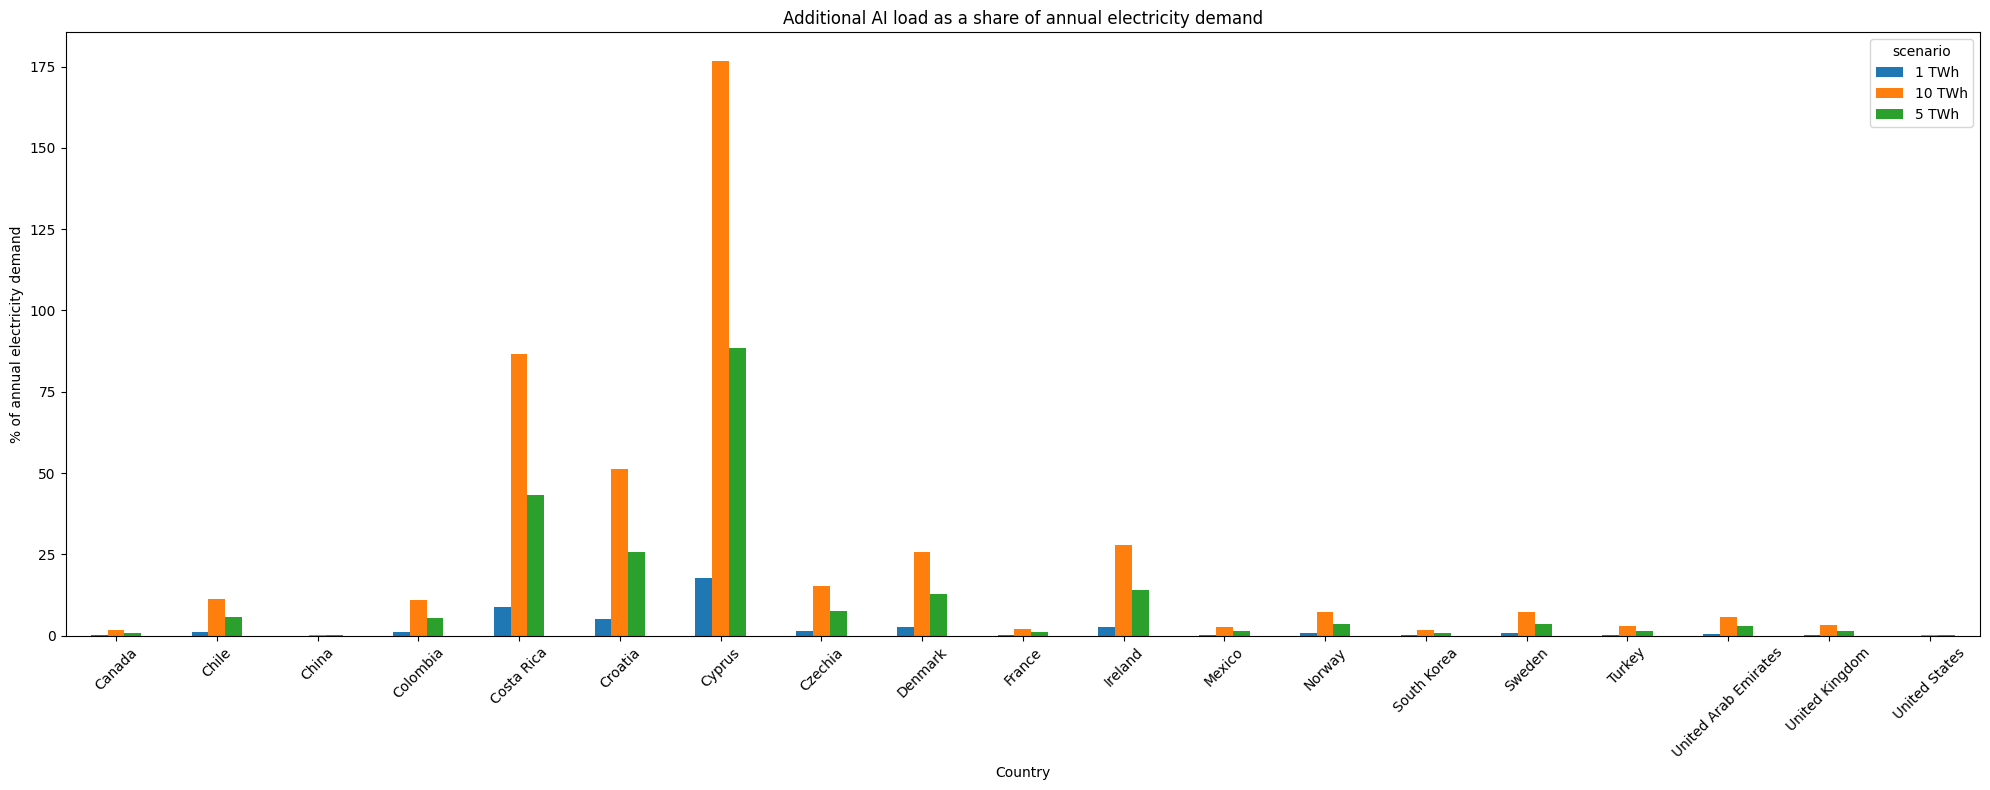

In [28]:
# =========================================
# 7. Bar chart: grouped bar chart
# =========================================
pivot_bar = plot_long.pivot(index="country", columns="scenario", values="share_pct")

pivot_bar.plot(kind="bar", figsize=(20, 8))
plt.title("Additional AI load as a share of annual electricity demand")
plt.ylabel("% of annual electricity demand")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

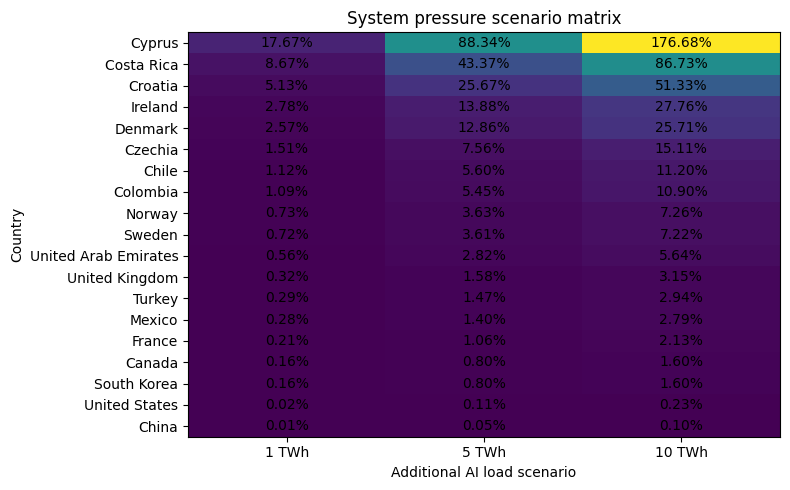

In [21]:
# =========================================
# 8. Heatmap
# =========================================
heatmap_df = df2024.set_index("country")[scenario_cols].copy()
heatmap_df.columns = ["1 TWh", "5 TWh", "10 TWh"]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

plt.title("System pressure scenario matrix")
plt.xlabel("Additional AI load scenario")
plt.ylabel("Country")

for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        ax.text(
            j, i,
            f"{heatmap_df.iloc[i, j]:.2f}%",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

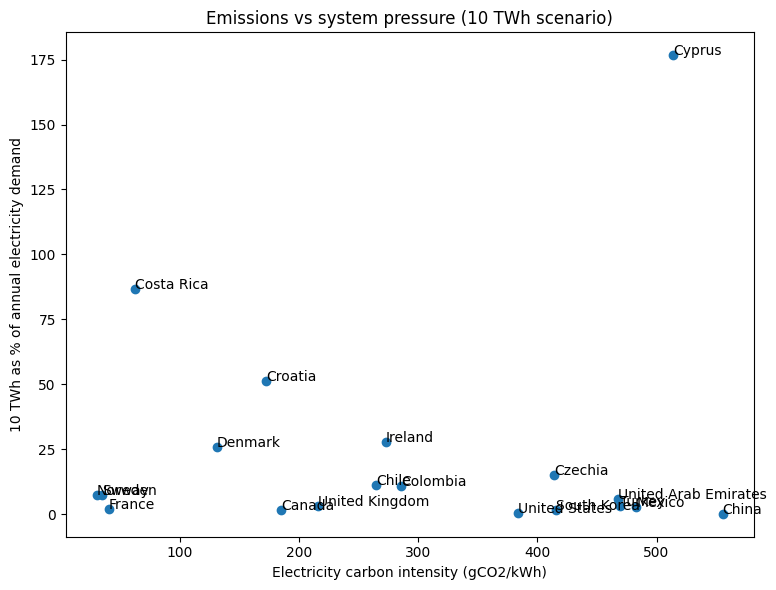

In [22]:
# =========================================
# 9. Scatter plot:
# carbon intensity vs pressure from 10 TWh
# Lower left corner = better:
# lower emissions + lower system pressure
# =========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df2024["carbon_intensity_elec"],
    df2024["share_10twh_pct"]
)

for _, row in df2024.iterrows():
    ax.text(
        row["carbon_intensity_elec"],
        row["share_10twh_pct"],
        row["country"]
    )

ax.set_title("Emissions vs system pressure (10 TWh scenario)")
ax.set_xlabel("Electricity carbon intensity (gCO2/kWh)")
ax.set_ylabel("10 TWh as % of annual electricity demand")
plt.tight_layout()
plt.show()

In [32]:
# =========================================
# 10. Short conclusions
# =========================================
worst_pressure_country = df2024.iloc[0]["country"]
best_pressure_country = df2024.iloc[-1]["country"]

canada_row = df2024.loc[df2024["country"] == "Canada"].iloc[0]

print("\n=== Short conclusions ===")
print(
    f"The country with the highest relative pressure under the 10 TWh scenario is: {worst_pressure_country}."
)
print(
    f"The country with the lowest relative pressure under the 10 TWh scenario is: {best_pressure_country}."
)
print(
    f"For Canada, 1 TWh = {canada_row['share_1twh_pct']:.2f}% of annual electricity demand, "
    f"5 TWh = {canada_row['share_5twh_pct']:.2f}%, "
    f"10 TWh = {canada_row['share_10twh_pct']:.2f}%."
)
print(
    f"According to the heuristic, the 10 TWh scenario for Canada looks like: {canada_row['pressure_10twh']} pressure."
)


=== Short conclusions ===
The country with the highest relative pressure under the 10 TWh scenario is: Cyprus.
The country with the lowest relative pressure under the 10 TWh scenario is: China.
For Canada, 1 TWh = 0.16% of annual electricity demand, 5 TWh = 0.80%, 10 TWh = 1.60%.
According to the heuristic, the 10 TWh scenario for Canada looks like: Moderate pressure.


In [31]:
print("\n=== Positive conclusion ===")
print("Canada wins not only in terms of relatively clean electricity, but also in terms of system scale.")
print("That is, the same AI load:causes a smaller share of the system pressure in Canada than in smaller power systems.")


=== Positive conclusion ===
Canada wins not only in terms of relatively clean electricity, but also in terms of system scale.
That is, the same AI load:causes a smaller share of the system pressure in Canada than in smaller power systems.


## What-if scenario

This scenario does not predict future AI demand directly.

Instead, it shows how sustainability positioning changes if:
- electricity demand rises
- low-carbon share improves

This helps move the presentation from description into recommendation.

In [ ]:
# =========================================
# What-if scenario analysis
# =========================================
scenario_df = df2024[[
    "country", "electricity_demand", "low_carbon_share_elec", "carbon_intensity_elec"
]].copy()

# Scenario: 20% growth in electricity demand
scenario_df["Electricity_20pct_Growth"] = scenario_df["electricity_demand"] * 1.20

# Scenario: Low-carbon share improves by 10 percentage points
scenario_df["Low_Carbon_Improved"] = scenario_df["low_carbon_share_elec"] + 10
scenario_df["Low_Carbon_Improved"] = scenario_df["Low_Carbon_Improved"].clip(upper=100)

print(scenario_df.head())